In [1]:
# Cell 1 — imports + path setup
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Your directory (as provided)
user_path = Path("../../../Cell_Division_Projects/Rockfish_NAMD/2_FtsQLBWI_DockedSite2-Build/metadynamics3/mtd156-160/mtd156-160.pmf")

# If running in an environment (where the attached file is copied), this will work:
attached_path = Path("./mtd156-160.pmf")

pmf_path = attached_path if attached_path.exists() else user_path
pmf_path

WindowsPath('mtd156-160.pmf')

In [2]:
# Cell 2 — PMF reader (handles the common "NAMD-style" pmf with # header lines)
def read_namd_pmf(path: Path):
    """
    Reads a NAMD metadynamics .pmf file of the form:

      # <ndim>
      # <min1> <dx1> <n1> <periodic1>
      # <min2> <dx2> <n2> <periodic2>
      ...
      <x1> <x2> <F>
      ...

    Returns:
      meta: dict
      df:   long-form dataframe with columns [cv1, cv2, ..., F]
    """
    path = Path(path)
    header = []
    data_start = 0

    with path.open("r") as f:
        for i, line in enumerate(f):
            s = line.strip()
            if not s:
                continue
            if s.startswith("#"):
                header.append(s)
            else:
                data_start = i
                break

    if len(header) < 1:
        raise ValueError("No header lines starting with '#' were found. Unexpected .pmf format.")

    # Parse ndim from first header line like "# 2"
    ndim = int(header[0].lstrip("#").strip().split()[0])

    if len(header) < 1 + ndim:
        raise ValueError(f"Header too short: expected at least {1+ndim} header lines, got {len(header)}.")

    axis_info = []
    for k in range(ndim):
        parts = header[1 + k].lstrip("#").strip().split()
        if len(parts) < 4:
            raise ValueError(f"Axis header line {k+1} malformed: {header[1+k]}")
        vmin = float(parts[0])
        dv = float(parts[1])
        n = int(float(parts[2]))
        periodic = int(float(parts[3]))
        axis_info.append(dict(vmin=vmin, dv=dv, n=n, periodic=periodic))

    # Load numeric body (ndim CV columns + 1 energy column)
    df = pd.read_csv(
        path,
        comment="#",
        delim_whitespace=True,
        header=None,
    )

    if df.shape[1] != ndim + 1:
        raise ValueError(f"Expected {ndim+1} columns (ndim CVs + F). Found {df.shape[1]} columns.")

    cv_cols = [f"cv{i+1}" for i in range(ndim)]
    df.columns = cv_cols + ["F"]

    meta = {
        "path": str(path),
        "ndim": ndim,
        "axis_info": axis_info,
        "header_lines": header,
    }
    return meta, df

meta, df = read_namd_pmf(pmf_path)
meta["ndim"], df.head(), df.shape


(2,
      cv1   cv2        F
 0  10.05  0.05  21.6149
 1  10.05  0.15  21.6149
 2  10.05  0.25  21.6149
 3  10.05  0.35  21.6149
 4  10.05  0.45  21.6149,
 (105000, 3))

In [3]:
# Cell 3 — Restructure to a 2D grid (for ndim=2) and build X, Y, Z arrays for plotting
def pmf_to_grid_2d(df: pd.DataFrame, cv1="cv1", cv2="cv2", F="F", sort=True):
    """
    Converts long-form rows (cv1, cv2, F) to grid arrays:
      x (unique cv1 values), y (unique cv2 values), Z (len(x) x len(y)) with Z[i,j]=F at (x[i], y[j]).
    """
    if sort:
        x = np.sort(df[cv1].unique())
        y = np.sort(df[cv2].unique())
    else:
        x = df[cv1].unique()
        y = df[cv2].unique()

    # Use pivot to make a matrix indexed by cv1 and columns=cv2
    Z = df.pivot(index=cv1, columns=cv2, values=F).reindex(index=x, columns=y).to_numpy()

    # Meshgrid for contour/heatmap plotting
    X, Y = np.meshgrid(y, x)  # note: X corresponds to columns (cv2), Y corresponds to rows (cv1)
    return x, y, X, Y, Z

if meta["ndim"] != 2:
    raise ValueError(f"This cell assumes a 2D PMF. Your file has ndim={meta['ndim']}.")

x1, x2, X, Y, Z = pmf_to_grid_2d(df)
x1[:5], x2[:5], Z.shape


(array([10.05, 10.15, 10.25, 10.35, 10.45]),
 array([0.05, 0.15, 0.25, 0.35, 0.45]),
 (300, 350))

In [4]:
# Cell 4 — Common cleanup: shift minimum to 0, and optionally mask "unvisited" plateaus
Z0 = Z - np.nanmin(Z)

# Optional: mask a constant "plateau" value that often corresponds to unvisited regions.
# If you'd rather not guess, keep this off.
mask_plateau = False
if mask_plateau:
    # Heuristic: if the most frequent value occupies a large fraction of the grid, mask it.
    vals, counts = np.unique(np.round(Z0, 6), return_counts=True)
    plateau_val = vals[np.argmax(counts)]
    frac = counts.max() / counts.sum()
    print("Heuristic plateau value:", plateau_val, "fraction:", frac)
    if frac > 0.10:  # adjust if desired
        Z0 = np.where(np.isclose(Z0, plateau_val), np.nan, Z0)

np.nanmin(Z0), np.nanmax(Z0)

(0.0, 21.6149)

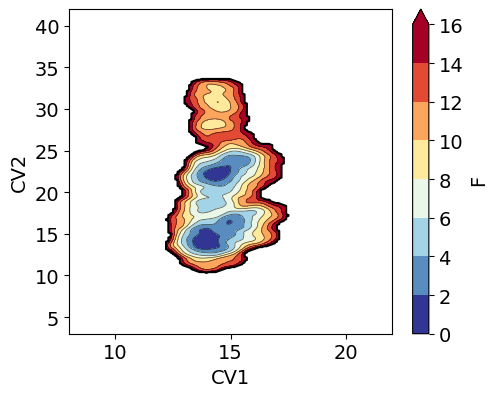

In [ ]:
# Cell 5 — Publication-style PMF contour plot
# Goal:
#   - Discrete (stepped) colormap like common metadynamics PMF figures
#   - Thin internal contour lines
#   - Thick black outline around the “accessible/sampled” region
#   - Axes swapped (so x=CV1, y=CV2) to match desired orientation

import matplotlib as mpl

mpl.rcParams.update({
    "font.size": 14,          # base font size
    "axes.titlesize": 14,     # title
    "axes.labelsize": 14,     # x/y labels
    "xtick.labelsize": 14,    # tick labels
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
    "figure.titlesize": 14,
})

# ----------------------------
# 1) Plotting scale / levels
# ----------------------------
# Upper limit of PMF (kcal/mol) shown in the color scale. Anything above this is masked out.
Fmax = 16.0

# Spacing between contour levels (1.0 gives 0,1,2,...,16)
dF = 2.0
levels = np.arange(0.0, Fmax + dF, dF)

# ----------------------------
# 2) Axis limits (edit as needed)
# ----------------------------
# Because we swap axes in contourf below (Y, X), the x-axis corresponds to CV1
# and the y-axis corresponds to CV2.
xlim = (8, 22)   # x-axis range (CV1)
ylim = (3, 42)   # y-axis range (CV2)

# ----------------------------
# 3) Define the accessible region
# ----------------------------
# Z0 should be your PMF shifted so min=0 (from Cell 4).
# mask_access defines where the PMF is both finite and within the plotted range.
mask_access = np.isfinite(Z0) & (Z0 <= Fmax)

# Create a plotting copy where anything outside the accessible region is NaN.
# This ensures contourf only fills the sampled region and leaves the outside blank.
Zp = Z0.copy()
Zp[~mask_access] = np.nan

# ----------------------------
# 4) Colormap (discrete steps)
# ----------------------------
# RdYlBu_r gives: blue (low) -> light -> yellow/orange -> red (high),
# similar to many published PMF examples.
# We discretize it into (len(levels)-1) bins so the colorbar is stepped.
cmap = plt.get_cmap("RdYlBu_r", len(levels) - 1)
norm = mpl.colors.BoundaryNorm(levels, cmap.N, clip=False)

# ----------------------------
# 5) Plot
# ----------------------------
plt.figure(figsize=(5.2, 4.2))

# Filled contours.
# IMPORTANT: (Y, X) swaps axes so x=CV1 and y=CV2.
cf = plt.contourf(
    Y, X, Zp,
    levels=levels,
    cmap=cmap,
    norm=norm,
    extend="max",
)

# Thin contour lines overlaid for readability (like in typical PMF figures).
plt.contour(
    Y, X, Zp,
    levels=levels,
    colors="k",
    linewidths=0.6,
    alpha=0.6,
)

# Thick black outline around the accessible region.
# We contour the binary mask boundary at 0.5 (between 0 and 1).
plt.contour(
    Y, X, mask_access.astype(float),
    levels=[0.5],
    colors="k",
    linewidths=1.5,
)

# Labels reflect the swapped axes
plt.xlabel("CV1")
plt.ylabel("CV2")

# Apply axis limits
plt.xlim(*xlim)
plt.ylim(*ylim)

# Colorbar formatting (ticks every 2 units, like many published examples)
cbar = plt.colorbar(cf, ticks=np.arange(0, Fmax + 0.1, 2))
cbar.set_label("F")

plt.tight_layout()
plt.show()


Start snapped to: (14.45, 32.05) index (44, 320)
Goal  snapped to: (13.95, 14.95) index (39, 149)
Path length (nodes): 172 total cost: 1041.6627798859013


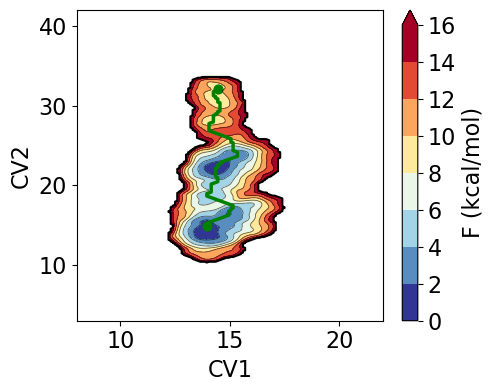

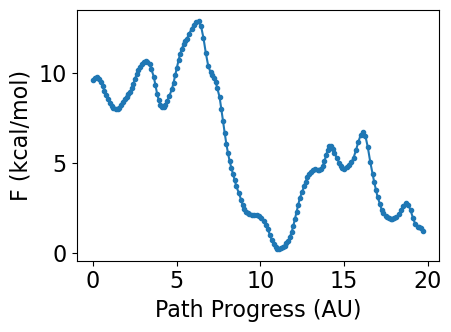

In [6]:
# Cell 7 — Lowest-energy path (LEP) on the PMF grid + overlay + F vs progress
#
# Method:
#   - Treat the PMF grid as a graph (8-neighbor connectivity).
#   - Use Dijkstra to find a minimum-cost path between two points.
#   - Cost per step = w_dist * (step length) + w_E * (PMF at next node)
#     (tunable tradeoff between geometric shortness and low energy)

import heapq
import numpy as np
import matplotlib.pyplot as plt

mpl.rcParams.update({
    "font.size": 16,          # base font size
    "axes.titlesize": 16,     # title
    "axes.labelsize": 16,     # x/y labels
    "xtick.labelsize": 16,    # tick labels
    "ytick.labelsize": 16,
    "legend.fontsize": 16,
    "figure.titlesize": 16,
})

# ----------------------------
# 1) Inputs: endpoints in (CV1, CV2)
# ----------------------------
start_cv1, start_cv2 = 14.5, 32.0
end_cv1,   end_cv2   = 14.0, 15.0

# ----------------------------
# 2) Tunable path cost weights
# ----------------------------
w_dist = 2.0   # weight on geometric distance
w_E    = 1.0   # weight on energy (PMF)

# ----------------------------
# 3) Helper: map CV values to nearest grid indices
# ----------------------------
def nearest_index(arr, val):
    arr = np.asarray(arr)
    return int(np.argmin(np.abs(arr - val)))

i0 = nearest_index(x1, start_cv1)   # x1 is CV1 axis values
j0 = nearest_index(x2, start_cv2)   # x2 is CV2 axis values
i1 = nearest_index(x1, end_cv1)
j1 = nearest_index(x2, end_cv2)

start = (i0, j0)
goal  = (i1, j1)

print("Start snapped to:", (x1[i0], x2[j0]), "index", start)
print("Goal  snapped to:", (x1[i1], x2[j1]), "index", goal)

# ----------------------------
# 4) Dijkstra on a masked grid (avoid NaNs / inaccessible region)
# ----------------------------
Z_use = Zp  # use your masked PMF (NaN outside sampled region)
valid = np.isfinite(Z_use)

if not valid[start] or not valid[goal]:
    raise ValueError("Start or goal is outside the valid/sampled region after masking (Zp has NaNs there).")

# grid spacing in CV units (approx; assumes axes are regular)
dx1 = float(np.median(np.diff(x1))) if len(x1) > 1 else 1.0
dx2 = float(np.median(np.diff(x2))) if len(x2) > 1 else 1.0

# 8-neighbor moves with geometric step lengths in CV-space
moves = []
for di in (-1, 0, 1):
    for dj in (-1, 0, 1):
        if di == 0 and dj == 0:
            continue
        step_len = np.sqrt((di * dx1)**2 + (dj * dx2)**2)
        moves.append((di, dj, step_len))

def dijkstra_path(Z, valid_mask, start, goal, w_dist=1.0, w_E=1.0, moves=moves):
    nrows, ncols = Z.shape
    INF = np.inf

    dist = np.full((nrows, ncols), INF, dtype=float)
    prev = np.full((nrows, ncols, 2), -1, dtype=int)

    si, sj = start
    gi, gj = goal

    dist[si, sj] = 0.0
    heap = [(0.0, si, sj)]

    while heap:
        dcur, i, j = heapq.heappop(heap)
        if dcur != dist[i, j]:
            continue
        if (i, j) == (gi, gj):
            break

        for di, dj, step_len in moves:
            ni, nj = i + di, j + dj
            if ni < 0 or ni >= nrows or nj < 0 or nj >= ncols:
                continue
            if not valid_mask[ni, nj]:
                continue

            # cost to enter neighbor: distance + energy penalty at neighbor
            step_cost = w_dist * step_len + w_E * float(Z[ni, nj])
            nd = dcur + step_cost

            if nd < dist[ni, nj]:
                dist[ni, nj] = nd
                prev[ni, nj, 0] = i
                prev[ni, nj, 1] = j
                heapq.heappush(heap, (nd, ni, nj))

    if not np.isfinite(dist[gi, gj]):
        raise RuntimeError("No path found (goal unreachable under current mask/weights).")

    # reconstruct
    path = []
    i, j = gi, gj
    while True:
        path.append((i, j))
        if (i, j) == (si, sj):
            break
        pi, pj = prev[i, j]
        if pi < 0:
            raise RuntimeError("Path reconstruction failed.")
        i, j = int(pi), int(pj)
    path.reverse()
    return path, dist[gi, gj]

path_idx, total_cost = dijkstra_path(Z_use, valid, start, goal, w_dist=w_dist, w_E=w_E)
print("Path length (nodes):", len(path_idx), "total cost:", total_cost)

# Convert indices -> CV coordinates and energies
cv1_path = np.array([x1[i] for i, j in path_idx], dtype=float)
cv2_path = np.array([x2[j] for i, j in path_idx], dtype=float)
F_path   = np.array([Z0[i, j] for i, j in path_idx], dtype=float)  # use shifted PMF (not masked)

# Progress variable: cumulative arc length in CV space
ds = np.sqrt(np.diff(cv1_path)**2 + np.diff(cv2_path)**2)
s = np.concatenate([[0.0], np.cumsum(ds)])

# ----------------------------
# 5) Overlay path on your existing PMF contour map
# ----------------------------
plt.figure(figsize=(5.2, 4.2))

# Reproduce your PMF plot (axes swapped: x=CV1, y=CV2)
cf = plt.contourf(
    Y, X, Zp,
    levels=levels,
    cmap=cmap,
    norm=norm,
    extend="max",
)
plt.contour(Y, X, Zp, levels=levels, colors="k", linewidths=0.6, alpha=0.6)
plt.contour(Y, X, valid.astype(float), levels=[0.5], colors="k", linewidths=1.5)

# Path overlay (note: plot in CV coordinates directly: x=CV1, y=CV2)
plt.plot(cv1_path, cv2_path, linewidth=2.5,color='green')
plt.scatter([cv1_path[0], cv1_path[-1]], [cv2_path[0], cv2_path[-1]], s=40,color='green')

plt.xlabel("CV1")
plt.ylabel("CV2")
plt.xlim(*xlim)
plt.ylim(*ylim)

cbar = plt.colorbar(cf, ticks=np.arange(0, Fmax + 0.1, 2))
cbar.set_label("F (kcal/mol)")

plt.tight_layout()

# --- for the contour + path overlay figure ---
plt.savefig("pmf_lep_overlay.png", dpi=300, bbox_inches="tight")
plt.savefig("pmf_lep_overlay.pdf", bbox_inches="tight")

plt.show()


# ----------------------------
# 6) Plot F vs progress along the path
# ----------------------------
plt.figure(figsize=(5.0, 3.6))
plt.plot(s, F_path, marker="o", linewidth=1.5, markersize=3)
plt.xlabel("Path Progress (AU)")
plt.ylabel("F (kcal/mol)")
plt.tight_layout()

# --- for the F vs progress figure ---
plt.savefig("pmf_lep_F_vs_progress.png", dpi=300, bbox_inches="tight")
plt.savefig("pmf_lep_F_vs_progress.pdf", bbox_inches="tight")

plt.show()